# Import LIBs

In [104]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split , GridSearchCV ,cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from xgboost import XGBRegressor


# Load data

In [82]:
df = pd.read_csv('housing.csv')

# EDA

In [83]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


* Null values in total_bedrooms
* ocean_proximity needed encoding

In [85]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Check null

In [86]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## Visulation

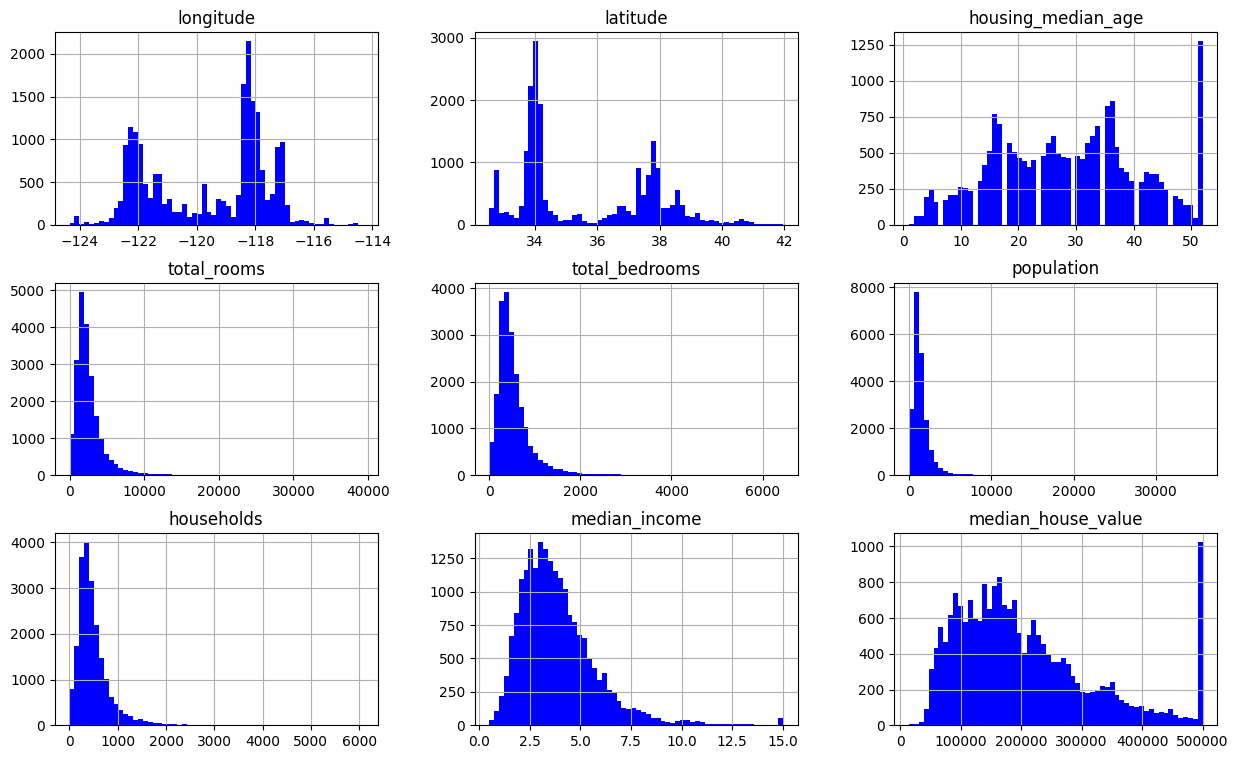

In [87]:
df.hist( bins=60  , figsize=(15 ,9) , color = 'blue')
plt.show()

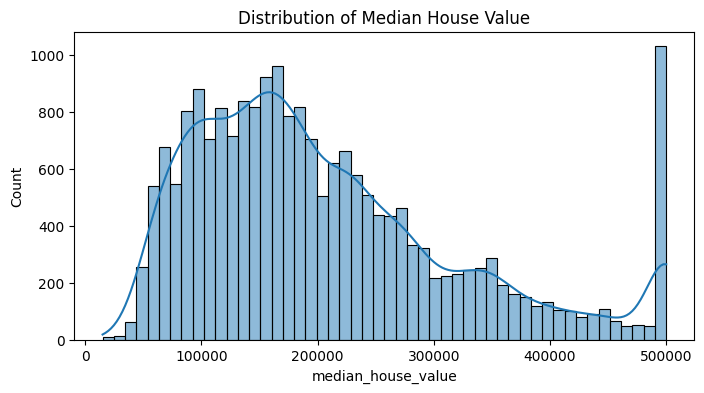

In [88]:
plt.figure(figsize=(8, 4))
sns.histplot(df['median_house_value'], bins=50, kde=True)
plt.title('Distribution of Median House Value')
plt.show()

## Heatmap

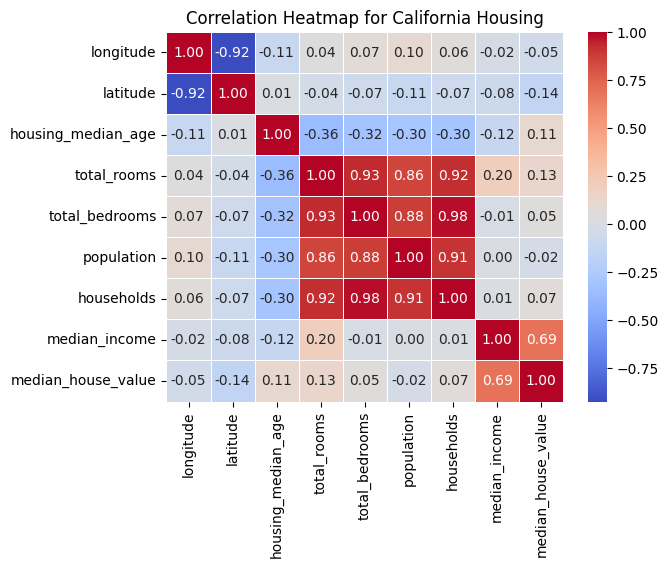

In [89]:
corr_matrix = df.corr(numeric_only=True)
plt.Figure(figsize=(14 ,8 ))
sns.heatmap(corr_matrix , annot=True , linewidths=0.5 , cmap='coolwarm' , fmt = '.2f')
plt.title('Correlation Heatmap for California Housing')
plt.show()

# Spilt Data



In [90]:
x = df.drop(columns='median_house_value')
y = df['median_house_value']

print(f' X shape :{x.shape}')
print(f' Y shape :{y.shape}')

x_train , x_test ,y_train , y_test = train_test_split(x , y  , random_state= 42 , test_size=0.2)

 X shape :(20640, 9)
 Y shape :(20640,)


# Feture Eng

In [91]:
x_train.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity'],
      dtype='str')

In [92]:
x_train['bedrooms per total_rooms'] = x_train['total_bedrooms'] / x_train['total_rooms']
x_train['households per bedrooms '] = x_train['households']/x_train['total_bedrooms'] 
x_train['population per households'] = x_train['population'] / x_train['households']
x_train["rooms_per_household"] = x_train["total_rooms"] / x_train["households"]

In [93]:
x_test['bedrooms per total_rooms'] = x_test['total_bedrooms'] / x_test['total_rooms']
x_test['households per bedrooms '] = x_test['households']/x_test['total_bedrooms'] 
x_test['population per households'] = x_test['population'] / x_test['households']
x_test["rooms_per_household"] = x_test["total_rooms"] / x_test["households"]

## Check corrleation

In [94]:
temp_df = x_train.copy()
temp_df['target'] = y_train

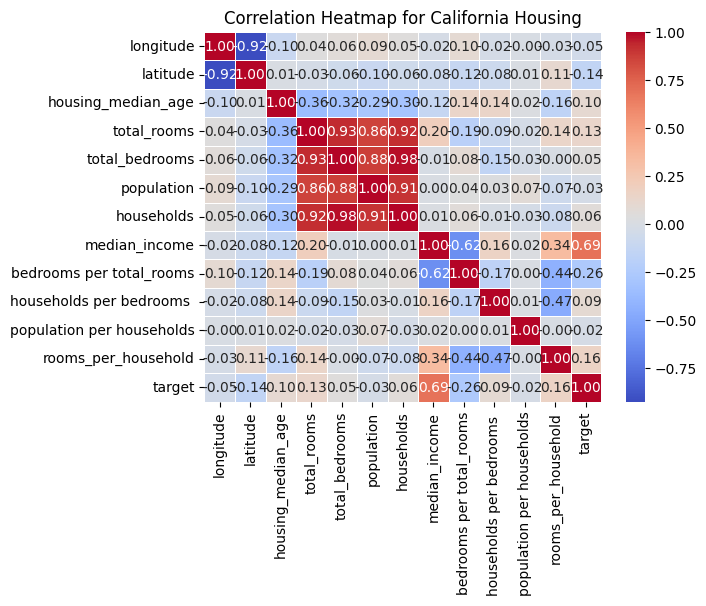

In [95]:
corr_matrix = temp_df.corr(numeric_only=True)
plt.Figure(figsize=(14 ,8 ))
sns.heatmap(corr_matrix , annot=True , linewidths=0.5 , cmap='coolwarm' , fmt = '.2f')
plt.title('Correlation Heatmap for California Housing')
plt.show()

## drop less corr Fetures

In [96]:
x_train.drop(columns=['total_bedrooms' ,'total_rooms', 'population', 'households' , 'population per households'],inplace=True)
x_test.drop(columns=['total_bedrooms' ,'total_rooms' ,'population', 'households', 'population per households'],inplace=True)


# Pipline

In [111]:
numeric_features = ['longitude', 'latitude', 'housing_median_age', 'median_income','bedrooms per total_rooms', 'households per bedrooms ', 'rooms_per_household']
categorical_features =['ocean_proximity']

numeric_pipeline = Pipeline([
    ("imputer" , SimpleImputer(strategy='median')),
    ('Scaler' , StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline,    numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model",        XGBRegressor(n_estimators=100, random_state=42)),
])


# Train

In [112]:
full_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

# CROSS VALIDATION

In [117]:
cv_scores = cross_val_score(
    full_pipeline, x_train, y_train, cv=5, scoring="r2"
)
print(f"\n── Cross Validation (cv=5) ")
print(f"  Scores : {cv_scores.round(3)}")


── Cross Validation (cv=5) 
  Scores : [0.821 0.819 0.831 0.817 0.823]


# EVALUATE Model
* (Hyperparameter Tuning)

In [116]:
y_pred = full_pipeline.predict(x_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"\n── Final Test Metrics ─────")
print(f"  MAE  : {mae:.2f}   ")
print(f"  RMSE : {rmse:.2f}  ")
print(f"  R²   : {r2:.3f}   ")



── Final Test Metrics ─────
  MAE  : 31302.43   
  RMSE : 47511.84  
  R²   : 0.828   


# HYPERPARAMETER TUNING

In [119]:

param_grid = {
    'model__n_estimators':  [100,  500 ,700],
    'model__max_depth':     [ 7 , 9 , 11],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample':     [0.8, 1.0],
}

grid = GridSearchCV(
    estimator  = full_pipeline,
    param_grid = param_grid,
    scoring    = 'r2',
    cv         = 5,
    n_jobs     = -1,
    
)

grid.fit(x_train, y_train)

print("\nBest Params:", grid.best_params_)
print(f"Best CV R²: {grid.best_score_:.4f}")




Best Params: {'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 700, 'model__subsample': 0.8}
Best CV R²: 0.8371


# EVALUATE (After Tuning)


In [120]:
y_pred_after = grid.predict(x_test)

print(f"\n── After Tuning ───────────")
print(f"  MAE  : {mean_absolute_error(y_test, y_pred_after):.2f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_after)):.2f}")
print(f"  R²   : {r2_score(y_test, y_pred_after):.3f}")


── After Tuning ───────────
  MAE  : 29666.61
  RMSE : 45666.20
  R²   : 0.841


# Vis  ACTUAL vs PREDICTED


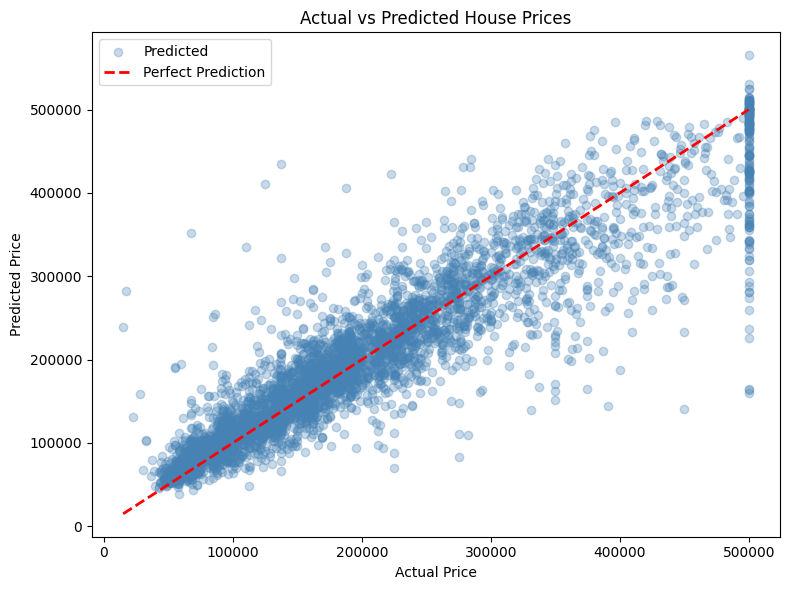

In [121]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_after, alpha=0.3, color='steelblue', label='Predicted')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()